In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import yfinance as yf
from datetime import date, datetime, time, timezone



In [2]:
def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data

entities = ["SPY", "IYW", "VT", "DBA", "TLT", "PDBC", "IAU"]

for ticker in entities:
    start_date = datetime(2023, 1, 1)
    end_date = datetime(2023, 12, 31)
    d = get_stock_data(ticker, start_date, end_date)
    print(ticker)
    print(d.head())

[*********************100%***********************]  1 of 1 completed


SPY
Price       Date       Close        High         Low        Open     Volume  \
0     2023-01-03  364.133911  369.498088  361.274902  367.528352   74850700   
1     2023-01-04  366.945160  368.972265  363.349899  366.390557   85934100   
2     2023-01-05  362.757050  365.109254  362.164220  364.994516   76970500   
3     2023-01-06  371.075867  372.194615  362.785768  365.845539  104189600   
4     2023-01-09  370.865509  376.449649  370.683861  373.265540   73978100   

Price Ticker  
0        SPY  
1        SPY  
2        SPY  
3        SPY  
4        SPY  


[*********************100%***********************]  1 of 1 completed


IYW
Price       Date      Close       High        Low       Open  Volume Ticker
0     2023-01-03  73.186058  75.214884  72.641744  74.502320  474900    IYW
1     2023-01-04  73.413712  73.888756  72.532906  73.700717  466800    IYW
2     2023-01-05  71.790649  72.899082  71.691684  72.899082  586700    IYW
3     2023-01-06  73.700706  74.047089  71.345288  72.433930  493200    IYW
4     2023-01-09  74.700272  76.125391  74.442955  74.442955  503100    IYW


[*********************100%***********************]  1 of 1 completed


...

TLT
Price       Date      Close       High        Low       Open    Volume Ticker
0     2023-01-03  87.818039  88.579715  87.281400  88.458539  25313200    TLT
1     2023-01-04  89.021126  89.566422  88.467179  89.341379  21678200    TLT
2     2023-01-05  89.393341  89.401998  88.095026  88.172928  14771100    TLT
3     2023-01-06  91.037872  91.141740  88.839391  88.891321  27473700    TLT
4     2023-01-09  91.522560  91.687015  90.250210  90.371392  21472200    TLT


[*********************100%***********************]  1 of 1 completed


PDBC
Price       Date      Close       High        Low       Open   Volume Ticker
0     2023-01-03  12.737313  12.984811  12.684278  12.905259  9766300   PDBC
1     2023-01-04  12.480975  12.578206  12.427940  12.534011  5159500   PDBC
2     2023-01-05  12.427941  12.507494  12.374906  12.445619  3305800   PDBC
3     2023-01-06  12.507494  12.587047  12.445620  12.534012  4234800   PDBC
4     2023-01-09  12.684278  12.816866  12.660412  12.710796  5908000   PDBC


[*********************100%***********************]  1 of 1 completed

IAU
Price       Date      Close       High        Low       Open   Volume Ticker
0     2023-01-03  34.880001  35.099998  34.680000  34.939999  9173200    IAU
1     2023-01-04  35.209999  35.299999  35.049999  35.259998  6501000    IAU
2     2023-01-05  34.790001  34.869999  34.630001  34.840000  5035900    IAU
3     2023-01-06  35.430000  35.480000  34.919998  35.009998  5675800    IAU
4     2023-01-09  35.500000  35.700001  35.459999  35.590000  7575200    IAU


In [4]:
SPY = get_stock_data("SPY", start_date, end_date)
IYW = get_stock_data("IYW", start_date, end_date)
VT = get_stock_data("VT", start_date, end_date)
DBA = get_stock_data("DBA", start_date, end_date)
TLT = get_stock_data("TLT", start_date, end_date)
PDBC = get_stock_data("PDBC", start_date, end_date)
IAU = get_stock_data("IAU", start_date, end_date)


SPY = SPY.reset_index().pivot(index='Date', columns='Ticker', values='Close')
IYW = IYW.reset_index().pivot(index='Date', columns='Ticker', values='Close')
VT = VT.reset_index().pivot(index='Date', columns='Ticker', values='Close')
DBA = DBA.reset_index().pivot(index='Date', columns='Ticker', values='Close')
TLT = TLT.reset_index().pivot(index='Date', columns='Ticker', values='Close')
PDBC = PDBC.reset_index().pivot(index='Date', columns='Ticker', values='Close')
IAU = IAU.reset_index().pivot(index='Date', columns='Ticker', values='Close')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [10]:
stock = pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU], axis=1, join='outer')

stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2023-01-03,364.133911,73.186058,80.617882,17.672842,87.818039,12.737313,34.880001
2023-01-04,366.945160,73.413712,81.608772,17.460022,89.021126,12.480975,35.209999
2023-01-05,362.757050,71.790649,80.767448,17.415686,89.393341,12.427941,34.790001
2023-01-06,371.075867,73.700706,82.618385,17.344746,91.037872,12.507494,35.430000
2023-01-09,370.865509,74.700272,82.814697,17.406818,91.522560,12.684278,35.500000


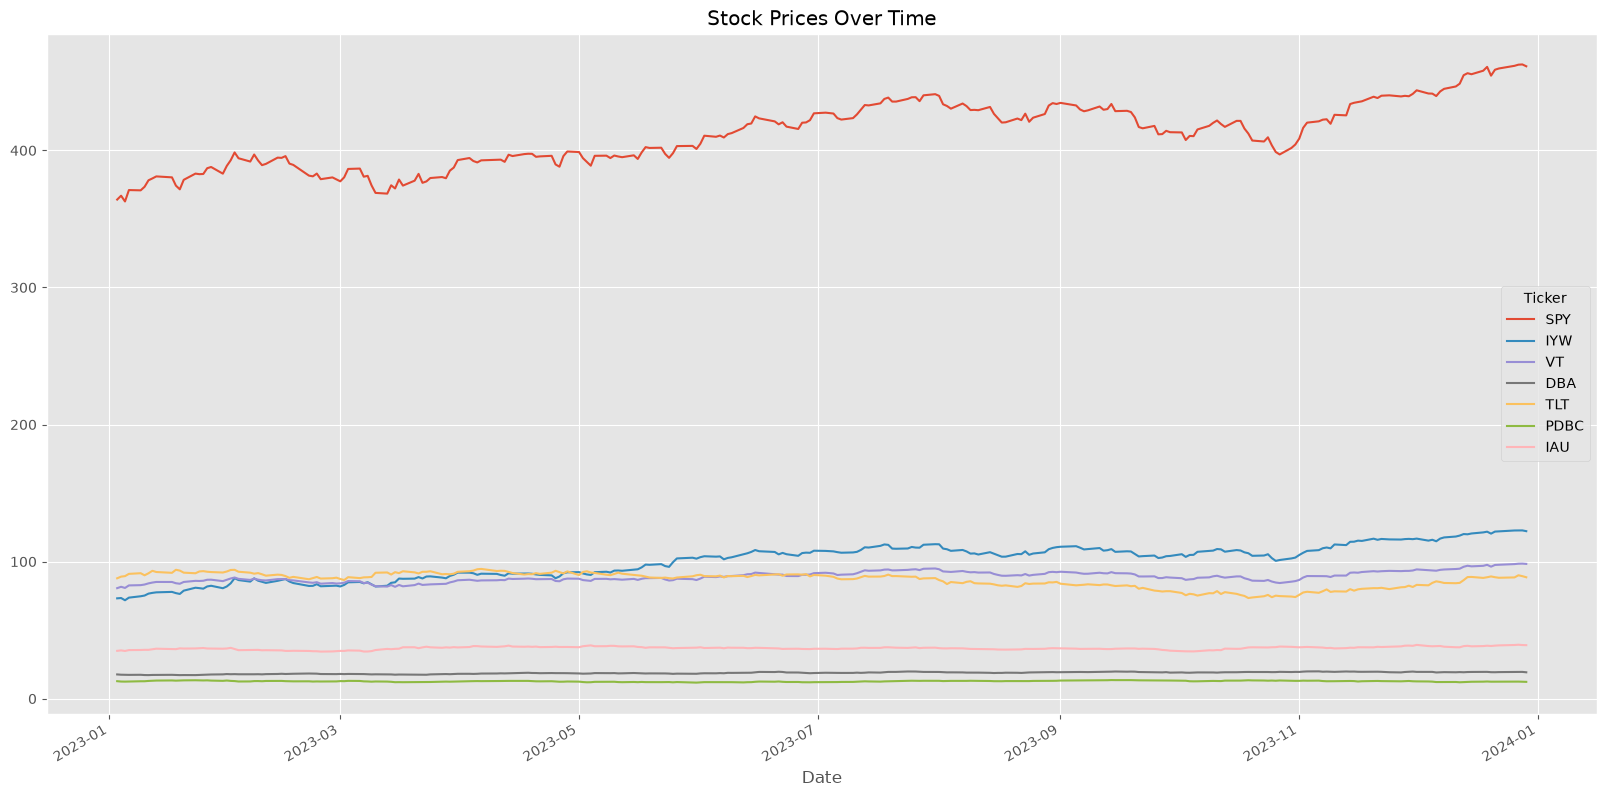

In [11]:
plt.style.use("ggplot")
stock.plot(figsize=(20, 10), title="Stock Prices Over Time")
plt.show()

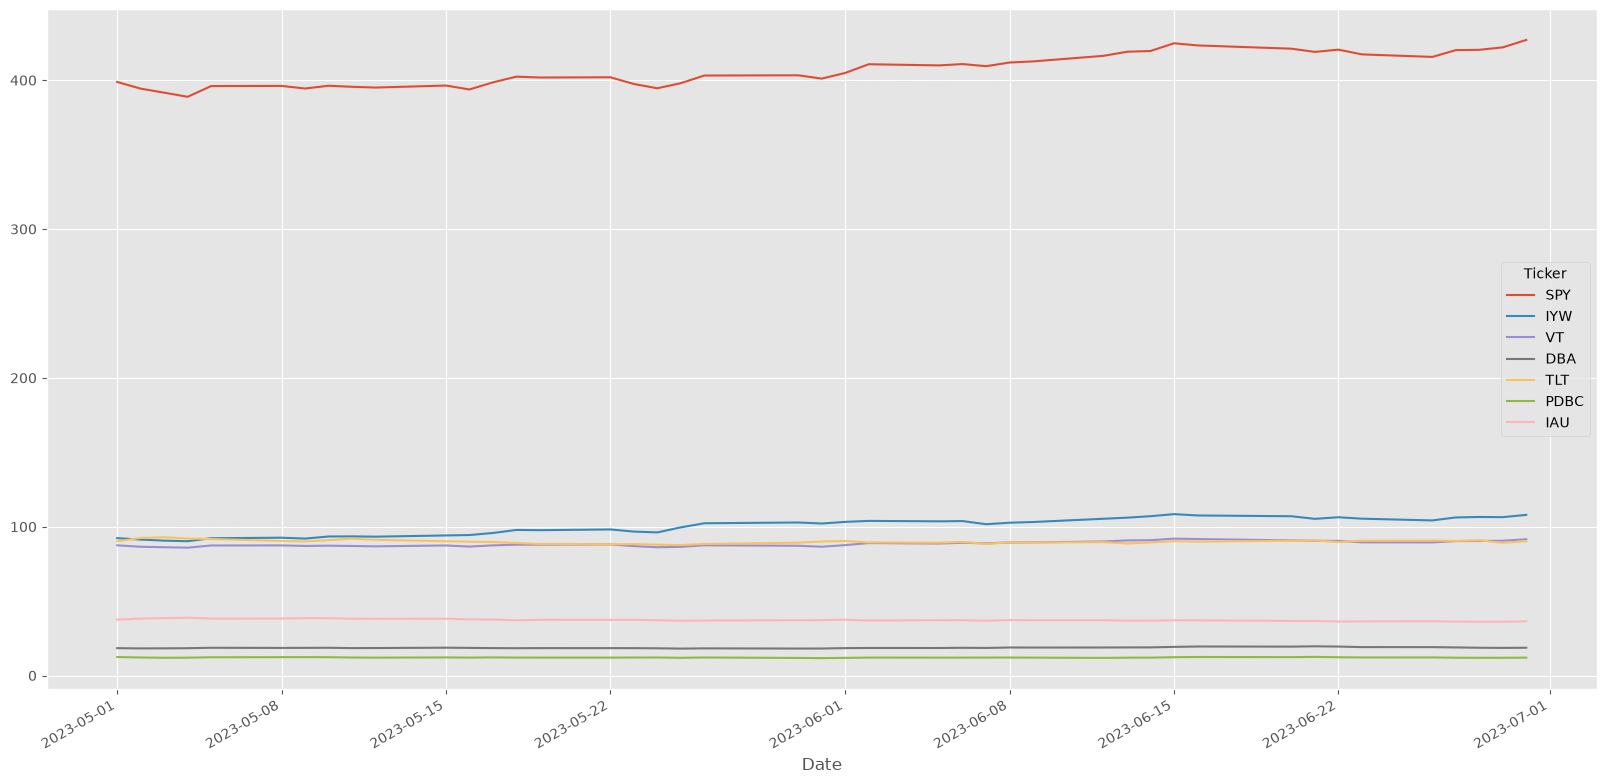

In [14]:
macro_shock = stock['2023-05-01':'2023-07-01']
plt.style.use("ggplot")
macro_shock.plot(figsize=(20, 10))
plt.show()


In [18]:

import flask

for i in dir(flask):
    print(i)

Blueprint
Config
Flask
Request
Response
__builtins__
__cached__
__doc__
__file__
__getattr__
__loader__
__name__
__package__
__path__
__spec__
abort
after_this_request
annotations
app
appcontext_popped
appcontext_pushed
appcontext_tearing_down
before_render_template
blueprints
cli
config
copy_current_request_context
ctx
current_app
flash
g
get_flashed_messages
get_template_attribute
globals
got_request_exception
has_app_context
has_request_context
helpers
json
jsonify
logging
make_response
message_flashed
redirect
render_template
render_template_string
request
request_finished
request_started
request_tearing_down
sansio
send_file
send_from_directory
session
sessions
signals
stream_template
stream_template_string
stream_with_context
t
template_rendered
templating
typing
url_for
wrappers
